# Predict Housing Price, Explore the dataset

In [1]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 設定中文字體支持（macOS）
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'STHeiti', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

# 檢查可用字體
available_fonts = [f.name for f in fm.fontManager.ttflist]
has_simhei = any('SimHei' in f for f in available_fonts)
has_stheiti = any('STHeiti' in f or 'Heiti' in f for f in available_fonts)
print(f"✓ 可用字體檢查 - SimHei: {has_simhei}, STHeiti: {has_stheiti}")

/Users/cliffyang/Program/ML-Program/ML_Basics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ 可用字體檢查 - SimHei: False, STHeiti: True


In [2]:
# Download latest version

path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset", output_dir="data", force_download=True)

print("Path to dataset files:", path)

100%|██████████| 185k/185k [00:00<00:00, 370kB/s]

Extracting files...
Path to dataset files: data


# 1. EDA

In [3]:
raw_df = pd.read_csv("data/AmesHousing.csv")
print(f"資料欄位: {len(raw_df.columns)}")
print(raw_df.columns)

資料欄位: 82
Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt

### 1.1 畫出數值資料分布直方圖

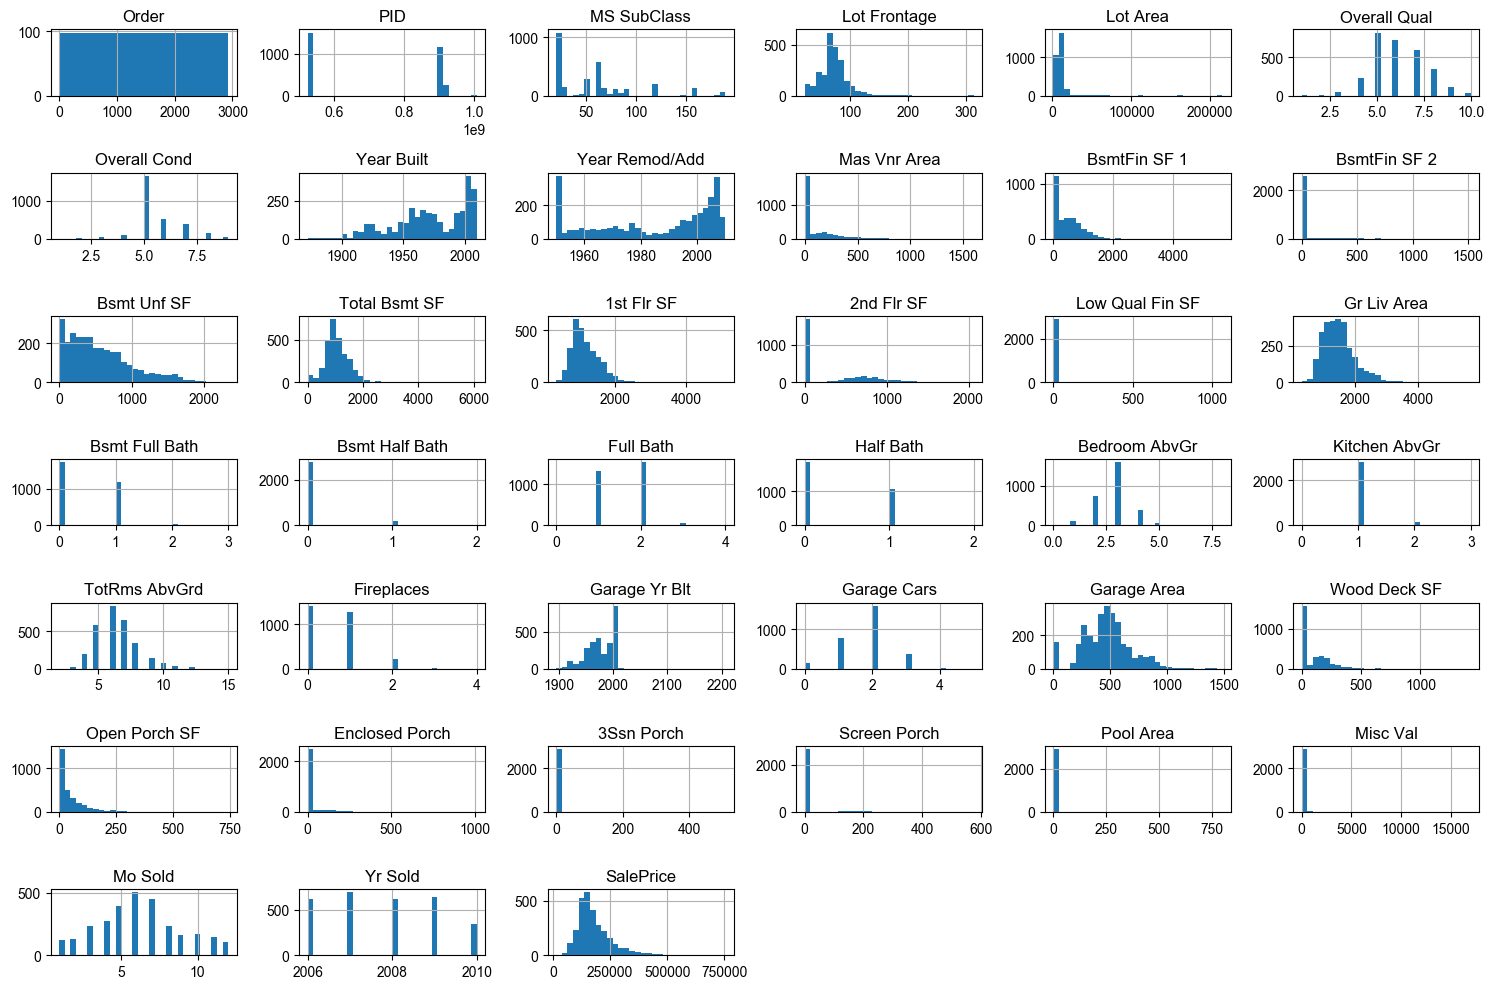

In [4]:
raw_df.hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

### 1.2 分類數值資料和類別資料

In [5]:
numeric_df = raw_df.select_dtypes(include=['number'])

categorical_df = raw_df.select_dtypes(include=['object'])


print(f"Number of numeric features: {len(numeric_df.columns)}")
print(numeric_df.columns)
print(f"Number of categorical features: {len(categorical_df.columns)}")  
print(categorical_df.columns)

Number of numeric features: 39
Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')
Number of categorical features: 43
Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', '

/var/folders/tg/pb3hnpkd1n39j6v7t7db1hbr0000gn/T/ipykernel_10979/4194668309.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = raw_df.select_dtypes(include=['object'])


### 1.3 資料前處理


原始資料筆數: 2930
候選特徵數: 15

【缺失值欄位與處理方式】
                missing_count
Bsmt Full Bath              2
Total Bsmt SF               1
Garage Cars                 1
Garage Area                 1

數值特徵：用中位數填充，降低極端值對平均數的影響
  Total Bsmt SF: 1 個 -> 用中位數 990.0 填充
  Garage Cars: 1 個 -> 用中位數 2.0 填充
  Garage Area: 1 個 -> 用中位數 480.0 填充
  Bsmt Full Bath: 2 個 -> 用中位數 0.0 填充
類別特徵：保留缺失為 'Missing'，讓模型知道該類別原本缺資料
✅ 確認：所有缺失值已填充（2930 筆資料）

【Outlier 標註】
  Gr Liv Area > 4000 且 SalePrice < 300000: 3 筆
  Total Bsmt SF > 5000 且 SalePrice < 300000: 2 筆

被標註為不合理並刪除的 outlier：


,Gr Liv Area,Total Bsmt SF,SalePrice
1498,5642,6110.0,160000
2180,5095,5095.0,183850
2181,4676,3138.0,184750


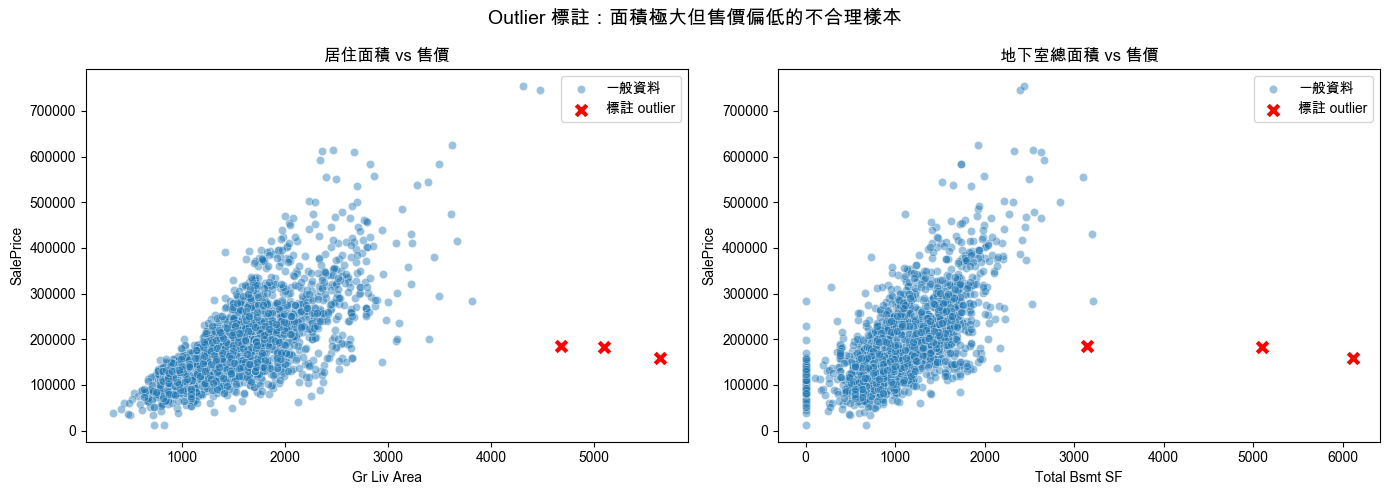

✅ 刪除 outlier 後資料筆數: 2927


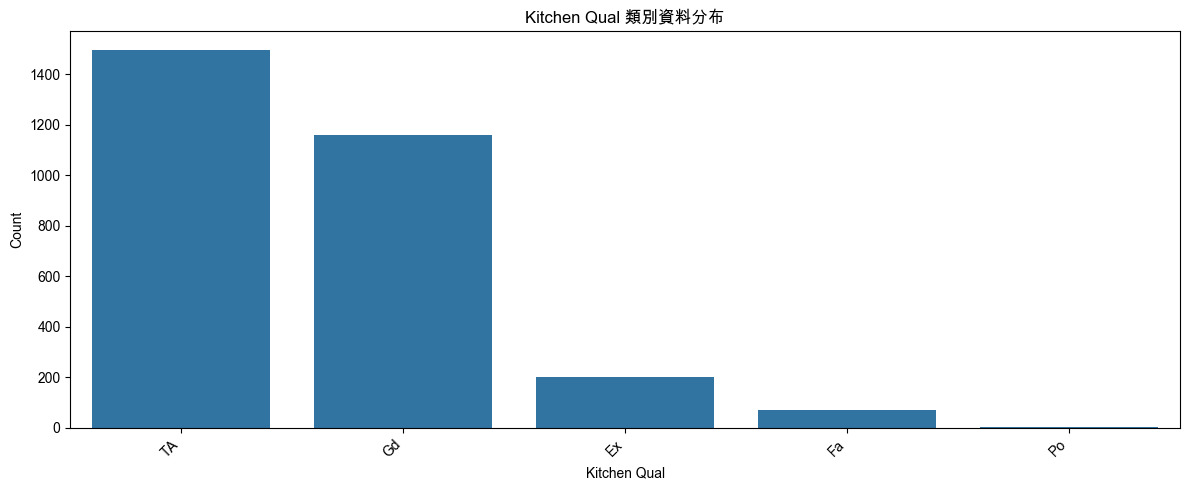

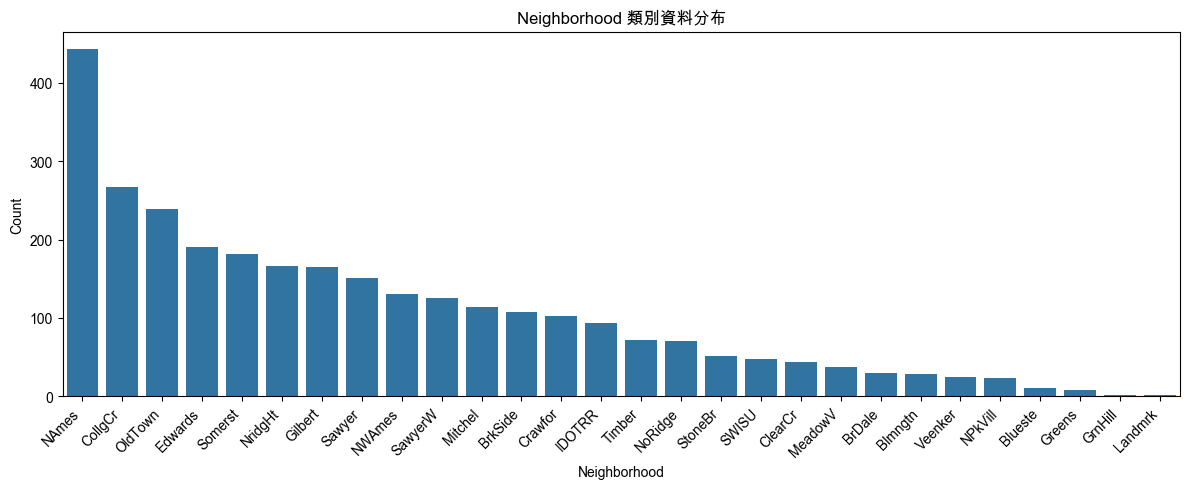

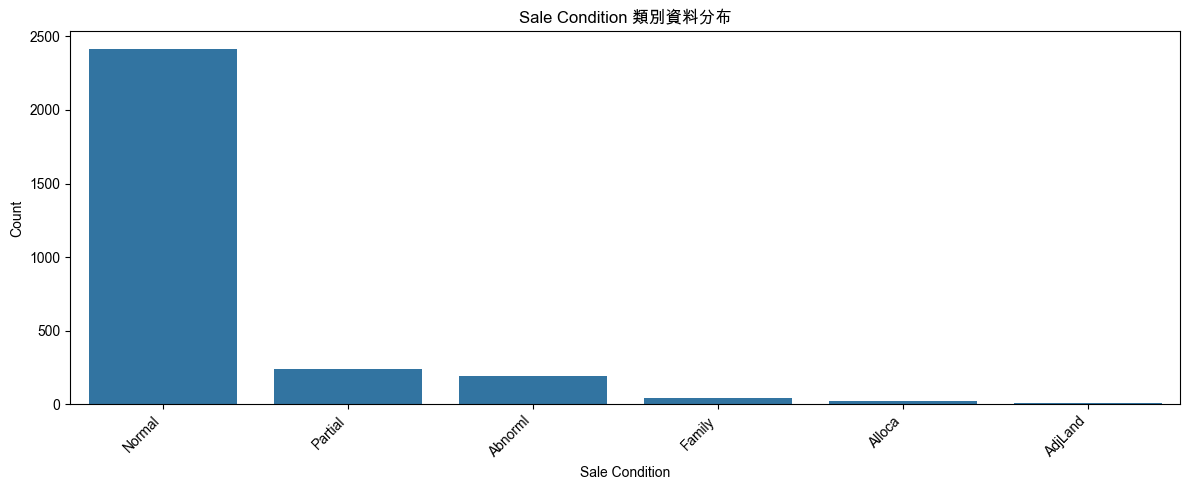

  Neighborhood: 28 個類別 -> 1 個 frequency encoded 特徵
  Sale Condition: 6 個類別 -> 1 個 frequency encoded 特徵
✅ 類別資料轉換完成，清理後資料形狀: (2927, 16)


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 候選特徵：先定義建模會用到的欄位，資料前處理只處理這批欄位與 SalePrice。
selected_features = ["Gr Liv Area", "Overall Qual", "Year Built",
                     "Total Bsmt SF", "Garage Cars", "Full Bath", "TotRms AbvGrd",
                     "Neighborhood", "Kitchen Qual", "Sale Condition",
                     "Garage Area", "Overall Cond", "Fireplaces", "Bsmt Full Bath",
                     "1st Flr SF"]


df = raw_df.copy()
clean_df = df[selected_features + ["SalePrice"]].copy()
print(f"原始資料筆數: {clean_df.shape[0]}")
print(f"候選特徵數: {len(selected_features)}")

# 1. 缺失值處理
numeric_cols = clean_df[selected_features].select_dtypes(include=['number']).columns.tolist()
categorical_cols = clean_df[selected_features].select_dtypes(include=['object']).columns.tolist()

missing_summary = clean_df[selected_features].isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print("\n【缺失值欄位與處理方式】")
if missing_summary.empty:
    print("  無缺失值")
else:
    print(missing_summary.to_frame('missing_count'))

print("\n數值特徵：用中位數填充，降低極端值對平均數的影響")
for col in numeric_cols:
    missing = clean_df[col].isnull().sum()
    if missing > 0:
        median_val = clean_df[col].median()
        clean_df[col] = clean_df[col].fillna(median_val)
        print(f"  {col}: {missing} 個 -> 用中位數 {median_val:.1f} 填充")

print("類別特徵：保留缺失為 'Missing'，讓模型知道該類別原本缺資料")
for col in categorical_cols:
    missing = clean_df[col].isnull().sum()
    if missing > 0:
        clean_df[col] = clean_df[col].fillna('Missing')
        print(f"  {col}: {missing} 個 -> 填入 'Missing' 類別")

assert clean_df[selected_features].isnull().sum().sum() == 0, "仍有缺失值！"
print(f"✅ 確認：所有缺失值已填充（{clean_df.shape[0]} 筆資料）")

# 2. Outlier 標記與刪除：面積極大但售價偏低，通常不符合一般房價趨勢。
outlier_masks = {
    'Gr Liv Area > 4000 且 SalePrice < 300000': (clean_df['Gr Liv Area'] > 4000) & (clean_df['SalePrice'] < 300000),
    'Total Bsmt SF > 5000 且 SalePrice < 300000': (clean_df['Total Bsmt SF'] > 5000) & (clean_df['SalePrice'] < 300000),
}
outlier_mask = pd.Series(False, index=clean_df.index)
print("\n【Outlier 標註】")
for rule, mask in outlier_masks.items():
    outlier_mask = outlier_mask | mask.fillna(False)
    print(f"  {rule}: {mask.sum()} 筆")

outlier_cols = ['Gr Liv Area', 'Total Bsmt SF', 'SalePrice']
outlier_points = clean_df.loc[outlier_mask, outlier_cols].copy()
print("\n被標註為不合理並刪除的 outlier：")
display(outlier_points if not outlier_points.empty else pd.DataFrame(columns=outlier_cols))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_specs = [
    ('Gr Liv Area', 'SalePrice', '居住面積 vs 售價'),
    ('Total Bsmt SF', 'SalePrice', '地下室總面積 vs 售價'),
]
for ax, (x_col, y_col, title) in zip(axes, scatter_specs):
    sns.scatterplot(data=clean_df, x=x_col, y=y_col, ax=ax, alpha=0.45, s=35, label='一般資料')
    if not outlier_points.empty:
        sns.scatterplot(data=clean_df.loc[outlier_mask], x=x_col, y=y_col, ax=ax, color='red', s=120, marker='X', label='標註 outlier')
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
plt.suptitle('Outlier 標註：面積極大但售價偏低的不合理樣本', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

clean_df = clean_df.loc[~outlier_mask].copy()
print(f"✅ 刪除 outlier 後資料筆數: {clean_df.shape[0]}")

# 類別資料分布圖：先觀察類別特徵的樣本分布，再進行數值轉換。
plot_categorical_cols = [col for col in ['Kitchen Qual', 'Neighborhood', 'Sale Condition'] if col in clean_df.columns]
for col in plot_categorical_cols:
    plt.figure(figsize=(12, 5))
    order = clean_df[col].value_counts().index
    sns.countplot(data=clean_df, x=col, order=order)
    plt.title(f'{col} 類別資料分布')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3. 資料型態轉換：類別資料轉成數值資料
# Kitchen Qual 是有順序的品質等級，使用 ordinal encoding。
quality_order = {'Missing': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
if 'Kitchen Qual' in clean_df.columns:
    clean_df['Kitchen Qual'] = clean_df['Kitchen Qual'].map(quality_order).astype(int)

# Neighborhood 類別數較多，不使用 one-hot，避免維度膨脹。
# 名目類別使用 frequency encoding：每個類別只轉成 1 個數值欄位，且不使用 SalePrice 避免資料洩漏。
frequency_encode_cols = [col for col in ['Neighborhood', 'Sale Condition'] if col in clean_df.columns]
frequency_encoding_maps = {}

for col in frequency_encode_cols:
    frequency_map = clean_df[col].value_counts(normalize=True).to_dict()
    frequency_encoding_maps[col] = frequency_map
    clean_df[f'{col}_frequency'] = clean_df[col].map(frequency_map).fillna(0)
    clean_df = clean_df.drop(columns=col)
    selected_features = [f'{col}_frequency' if feature == col else feature for feature in selected_features]
    print(f"  {col}: {len(frequency_map)} 個類別 -> 1 個 frequency encoded 特徵")

print(f"✅ 類別資料轉換完成，清理後資料形狀: {clean_df.shape}")


## 2. 特徵工程


corr(X, y) = cov(X, y) / (std(X) * std(y))

corr =  0.80 -> R² = 0.64
corr = -0.70 -> R² = 0.49
corr =  0.20 -> R² = 0.04

清理缺失值與 outlier 後，以 abs(corr) 排序的前15個數值特徵:
                              corr  abs_corr       R^2
Overall Qual              0.802592  0.802592  0.644155
Gr Liv Area               0.727122  0.727122  0.528706
Kitchen Qual              0.674800  0.674800  0.455355
Total Bsmt SF             0.660482  0.660482  0.436236
Garage Cars               0.648391  0.648391  0.420411
1st Flr SF                0.645589  0.645589  0.416785
Garage Area               0.644352  0.644352  0.415189
Year Built                0.558918  0.558918  0.312389
Full Bath                 0.546369  0.546369  0.298519
TotRms AbvGrd             0.500005  0.500005  0.250005
Fireplaces                0.476386  0.476386  0.226944
Bsmt Full Bath            0.276593  0.276593  0.076504
Neighborhood_frequency   -0.197105  0.197105  0.038851
Sale Condition_frequency -0.133880  0.133880  0.017924
Overall Cond             -0.101741  0.101741  0.010351


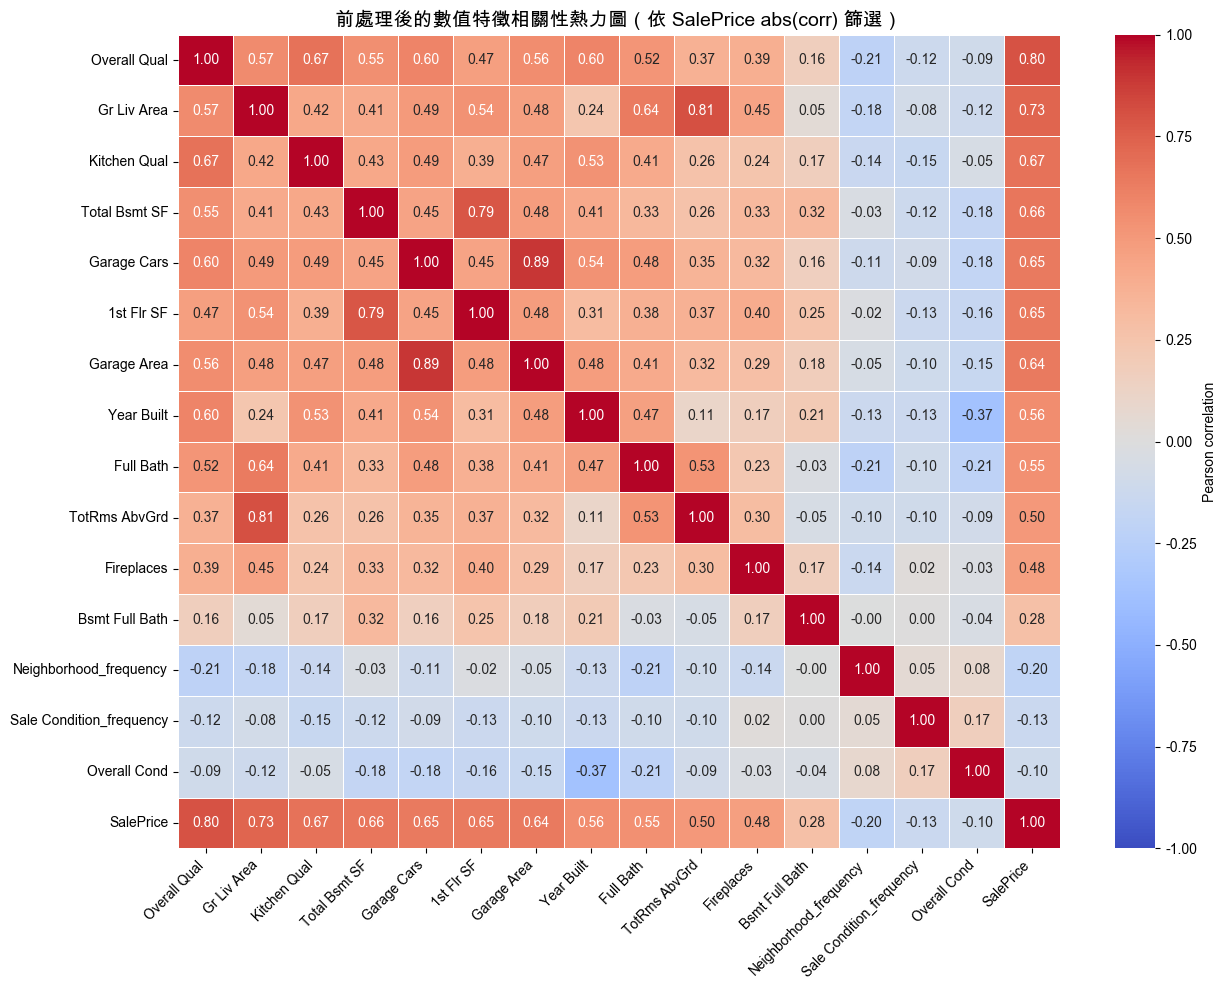


【偏態特徵 log1p 轉換】
  Gr Liv Area: skew 0.977 -> -0.036
  Total Bsmt SF: skew 0.412 -> -4.981
  Garage Area: skew 0.213 -> -3.531
  1st Flr SF: skew 0.951 -> -0.005
最終選取特徵數（依 abs(corr)）: 15
['Overall Qual', 'Gr Liv Area', 'Kitchen Qual', 'Total Bsmt SF', 'Garage Cars', '1st Flr SF', 'Garage Area', 'Year Built', 'Full Bath', 'TotRms AbvGrd', 'Fireplaces', 'Bsmt Full Bath', 'Neighborhood_frequency', 'Sale Condition_frequency', 'Overall Cond']


In [7]:
# Feature Selection：用清理後資料比較數值特徵與 SalePrice 的 corr，並以 abs(corr) 排名。
numeric_clean_df = clean_df.select_dtypes(include=['number'])
corr_matrix = numeric_clean_df.corr()
saleprice_corr = corr_matrix['SalePrice'].drop('SalePrice')
saleprice_abs_corr = saleprice_corr.abs().sort_values(ascending=False)
saleprice_r2 = saleprice_corr.pow(2)

print("=" * 60)
print("清理缺失值與 outlier 後，以 abs(corr) 排序的前15個數值特徵:")
print(pd.DataFrame({
    'corr': saleprice_corr.reindex(saleprice_abs_corr.head(15).index),
    'abs_corr': saleprice_abs_corr.head(15),
    'R^2': saleprice_r2.reindex(saleprice_abs_corr.head(15).index)
}))
print("=" * 60)

corr_feature_count = 15
top_corr_features = saleprice_abs_corr.head(corr_feature_count).index.tolist()
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix.loc[top_corr_features + ['SalePrice'], top_corr_features + ['SalePrice']],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)
plt.title('前處理後的數值特徵相關性熱力圖（依 SalePrice abs(corr) 篩選）', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 最終建模特徵：直接使用 abs(corr) 排名選出的特徵作為模型輸入。
model_features = top_corr_features
feature_df = clean_df[model_features].copy()
target_df = clean_df['SalePrice'].copy()

# 偏態特徵轉換：面積類特徵通常右偏，使用 log1p 壓縮極端大值並保留 0。
log_transform_cols = [
    'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', '1st Flr SF'
]
log_transform_cols = [col for col in log_transform_cols if col in feature_df.columns]

print("\n【偏態特徵 log1p 轉換】")
for col in log_transform_cols:
    skew_before = feature_df[col].skew()
    feature_df[col] = np.log1p(feature_df[col])
    skew_after = feature_df[col].skew()
    print(f"  {col}: skew {skew_before:.3f} -> {skew_after:.3f}")

print(f"最終選取特徵數（依 abs(corr)）: {len(feature_df.columns)}")
print(feature_df.columns.tolist())


In [8]:
# Feature Scaling：先分割資料，再只用訓練集 fit scaler，避免資料洩漏。
X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target_df, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"訓練集大小: {X_train.shape}")
print(f"測試集大小: {X_test.shape}")
print(f"目標值範圍: ${y_train.min():,.0f} ~ ${y_train.max():,.0f}")
print(f"\n特徵標準化：X_train 均值 {X_train_scaled.mean():.6f}, 標準差 {X_train_scaled.std():.6f}")
print(f"目標標準化：y_train 均值 {y_train_scaled.mean():.6f}, 標準差 {y_train_scaled.std():.6f}")


訓練集大小: (2341, 15)
測試集大小: (586, 15)
目標值範圍: $12,789 ~ $745,000

特徵標準化：X_train 均值 0.000000, 標準差 1.000000
目標標準化：y_train 均值 -0.000000, 標準差 1.000000


## 3. 模型訓練與比較

Epoch  50 | Train MSE: 0.0912 | Test MSE: 0.0858
Epoch 100 | Train MSE: 0.0858 | Test MSE: 0.0930
Epoch 150 | Train MSE: 0.0743 | Test MSE: 0.0787
Epoch 200 | Train MSE: 0.0667 | Test MSE: 0.0790
Epoch 250 | Train MSE: 0.0675 | Test MSE: 0.0849
Epoch 300 | Train MSE: 0.0676 | Test MSE: 0.0814
MLP Neural Network:
  【標準化單位】MAE: 0.1922  RMSE: 0.2853  R²: 0.9398
  【原始單位】MAE: $14,844  RMSE: $22,034


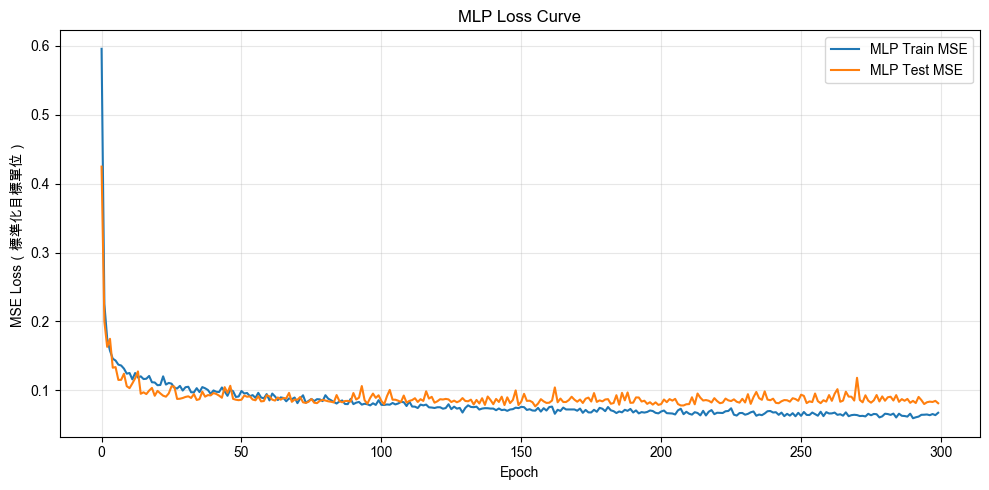

In [9]:
# # MLP
# X_train_scaled
# X_test_scaled
# y_train_scaled
# y_test_scaled
# scaler_y
# y_test

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

torch.manual_seed(42)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1,1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled.reshape(-1,1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)
    
model = MLPRegressor(input_dim=X_train_scaled.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 300
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor).item()

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1 ) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | Train MSE: {train_loss:.4f} | Test MSE: {test_loss:.4f}")

model.eval()

with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).cpu().numpy().ravel()

y_pred_original = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).ravel()

mlp_mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)
mlp_rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))
mlp_r2 = r2_score(y_test_scaled, y_pred_scaled)

mlp_mae_original = mean_absolute_error(y_test.values, y_pred_original)
mlp_rmse_original = np.sqrt(mean_squared_error(y_test.values, y_pred_original))

print("MLP Neural Network:")
print(f"  【標準化單位】MAE: {mlp_mae_scaled:.4f}  RMSE: {mlp_rmse_scaled:.4f}  R²: {mlp_r2:.4f}")
print(f"  【原始單位】MAE: ${mlp_mae_original:,.0f}  RMSE: ${mlp_rmse_original:,.0f}")
# 畫 loss curve：
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="MLP Train MSE")
plt.plot(test_losses, label="MLP Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss（標準化目標單位）")
plt.title("MLP Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



模型性能比較（用標準化的目標訓練）

Gradient Boosting:
  【Loss】Train MSE: 0.0200  Test MSE: 0.0778
  【標準化單位】MAE: 0.1894  RMSE: 0.2789  R²: 0.9424
  【原始單位】MAE: $14,629  RMSE: $21,545

Random Forest:
  【Loss】Train MSE: 0.0218  Test MSE: 0.0971
  【標準化單位】MAE: 0.2043  RMSE: 0.3117  R²: 0.9281
  【原始單位】MAE: $15,781  RMSE: $24,073

Linear Regression:
  【Loss】Train MSE: 0.1835  Test MSE: 0.2508
  【標準化單位】MAE: 0.3195  RMSE: 0.5008  R²: 0.8144
  【原始單位】MAE: $24,674  RMSE: $38,681

最佳模型: Gradient Boosting (R² = 0.9424)


,Train MSE,Test MSE
Gradient Boosting,0.020014,0.077811
Random Forest,0.021822,0.097139
Linear Regression,0.183481,0.250801


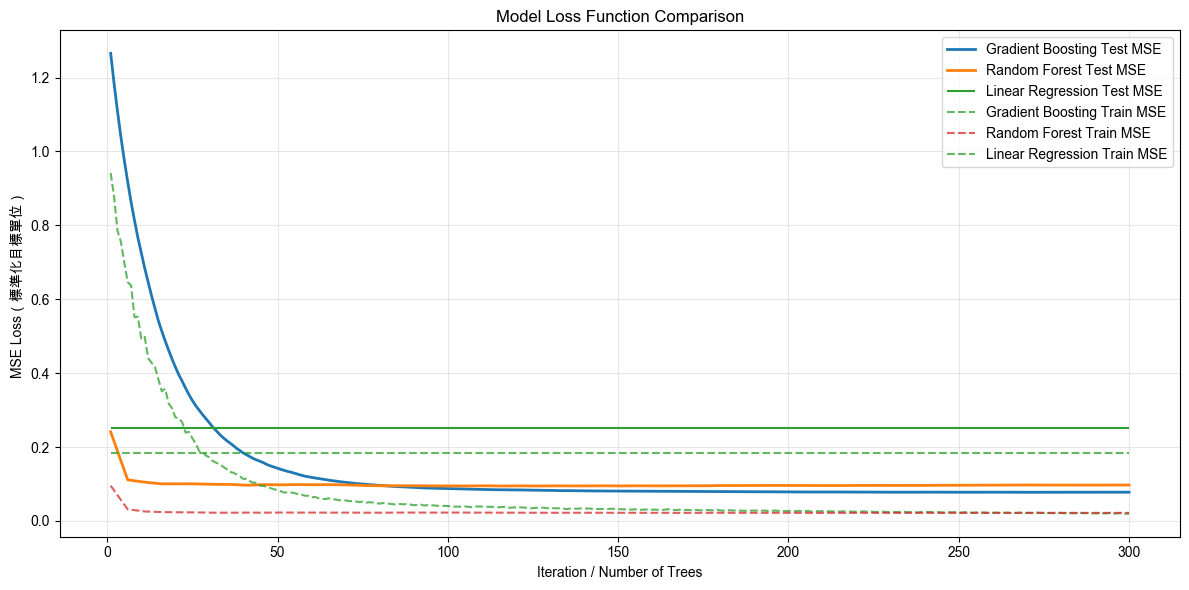

Gradient Boosting 最低 Test loss: iteration 274, MSE = 0.0776
Random Forest 最低 Test loss: 116 trees, MSE = 0.0946
Linear Regression Test loss baseline: MSE = 0.2508


In [10]:

models = {
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=5,
        subsample=0.8,
        min_samples_split=5,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    'Linear Regression': LinearRegression()
}

print("\n" + "=" * 70)
print("模型性能比較（用標準化的目標訓練）")
print("=" * 70)

best_model = None
best_r2 = -1
results_scaled = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_scaled)
    y_train_pred_scaled = model.predict(X_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)

    train_mse_scaled = mean_squared_error(y_train_scaled, y_train_pred_scaled)
    test_mse_scaled = mean_squared_error(y_test_scaled, y_pred_scaled)
    mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)
    r2_scaled = r2_score(y_test_scaled, y_pred_scaled)
    rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))

    y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    mae_original = mean_absolute_error(y_test.values, y_pred_original)
    rmse_original = np.sqrt(mean_squared_error(y_test.values, y_pred_original))

    results_scaled[name] = {
        'train_mse_scaled': train_mse_scaled,
        'test_mse_scaled': test_mse_scaled,
        'mae_scaled': mae_scaled,
        'rmse_scaled': rmse_scaled,
        'r2': r2_scaled,
        'mae_original': mae_original,
        'rmse_original': rmse_original,
        'model': model,
        'y_pred': y_pred_original
    }

    print(f"\n{name}:")
    print(f"  【Loss】Train MSE: {train_mse_scaled:.4f}  Test MSE: {test_mse_scaled:.4f}")
    print(f"  【標準化單位】MAE: {mae_scaled:.4f}  RMSE: {rmse_scaled:.4f}  R²: {r2_scaled:.4f}")
    print(f"  【原始單位】MAE: ${mae_original:,.0f}  RMSE: ${rmse_original:,.0f}")

    if r2_scaled > best_r2:
        best_r2 = r2_scaled
        best_model = model
        best_name = name
        best_y_pred = y_pred_original

print("\n" + "=" * 70)
print(f"最佳模型: {best_name} (R² = {best_r2:.4f})")
print("=" * 70)

# 三個模型的 Loss 下降比較：使用標準化目標單位的 MSE，數值越低越好。
loss_df = pd.DataFrame({
    model_name: {
        'Train MSE': result['train_mse_scaled'],
        'Test MSE': result['test_mse_scaled']
    }
    for model_name, result in results_scaled.items()
}).T

display(loss_df.sort_values('Test MSE'))

# Gradient Boosting：用 staged_predict 取得每一輪 boosting 的 loss。
gb_model = results_scaled['Gradient Boosting']['model']
gb_train_loss = gb_model.train_score_
gb_test_loss = [
    mean_squared_error(y_test_scaled, y_pred_stage)
    for y_pred_stage in gb_model.staged_predict(X_test_scaled)
]
gb_iterations = np.arange(1, len(gb_test_loss) + 1)

# Random Forest：用 warm_start 逐步增加樹數，觀察 loss 是否下降。
rf_base = results_scaled['Random Forest']['model']
rf_iterations = list(range(1, rf_base.n_estimators + 1, 5))
if rf_iterations[-1] != rf_base.n_estimators:
    rf_iterations.append(rf_base.n_estimators)

rf_loss_model = RandomForestRegressor(
    n_estimators=1,
    max_depth=rf_base.max_depth,
    min_samples_split=rf_base.min_samples_split,
    random_state=42,
    n_jobs=-1,
    warm_start=True
)
rf_train_loss = []
rf_test_loss = []
for n_estimators in rf_iterations:
    rf_loss_model.set_params(n_estimators=n_estimators)
    rf_loss_model.fit(X_train_scaled, y_train_scaled)
    rf_train_loss.append(mean_squared_error(y_train_scaled, rf_loss_model.predict(X_train_scaled)))
    rf_test_loss.append(mean_squared_error(y_test_scaled, rf_loss_model.predict(X_test_scaled)))

# Linear Regression 不是 iterative model，沒有 loss 下降過程；用水平線當 baseline。
lr_train_loss = results_scaled['Linear Regression']['train_mse_scaled']
lr_test_loss = results_scaled['Linear Regression']['test_mse_scaled']

plt.figure(figsize=(12, 6))
plt.plot(gb_iterations, gb_test_loss, label='Gradient Boosting Test MSE', linewidth=2)
plt.plot(rf_iterations, rf_test_loss, label='Random Forest Test MSE', linewidth=2)
plt.hlines(lr_test_loss, xmin=1, xmax=max(gb_iterations), colors='tab:green', linestyles='-', label='Linear Regression Test MSE')

plt.plot(gb_iterations, gb_train_loss, label='Gradient Boosting Train MSE', linewidth=1.5, linestyle='--', alpha=0.75)
plt.plot(rf_iterations, rf_train_loss, label='Random Forest Train MSE', linewidth=1.5, linestyle='--', alpha=0.75)
plt.hlines(lr_train_loss, xmin=1, xmax=max(gb_iterations), colors='tab:green', linestyles='--', alpha=0.75, label='Linear Regression Train MSE')

plt.xlabel('Iteration / Number of Trees')
plt.ylabel('MSE Loss（標準化目標單位）')
plt.title('Model Loss Function Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_gb_iter = int(np.argmin(gb_test_loss)) + 1
best_rf_iter = rf_iterations[int(np.argmin(rf_test_loss))]
print(f"Gradient Boosting 最低 Test loss: iteration {best_gb_iter}, MSE = {min(gb_test_loss):.4f}")
print(f"Random Forest 最低 Test loss: {best_rf_iter} trees, MSE = {min(rf_test_loss):.4f}")
print(f"Linear Regression Test loss baseline: MSE = {lr_test_loss:.4f}")



特徵重要性排序:
--------------------------------------------------
1. Overall Qual        : 0.5810
2. Gr Liv Area         : 0.1440
3. Total Bsmt SF       : 0.0528
4. 1st Flr SF          : 0.0387
5. Year Built          : 0.0351
6. Garage Area         : 0.0315
7. Kitchen Qual        : 0.0268
8. Full Bath           : 0.0163
9. Neighborhood_frequency: 0.0141
10. Fireplaces          : 0.0141


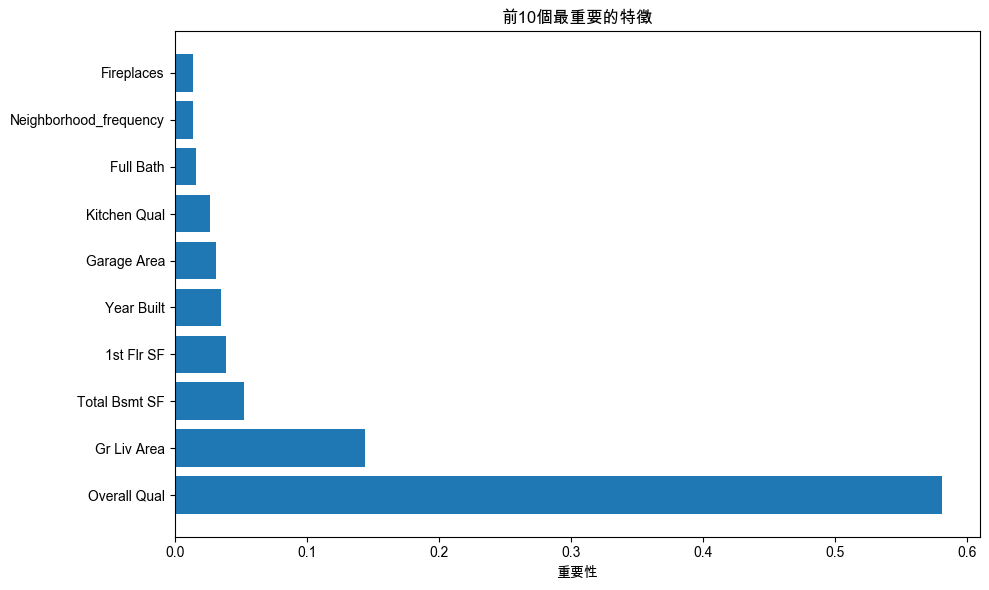

In [11]:
# 特徵重要性分析

feature_names = feature_df.columns.tolist()

# 獲取特徵重要性（適用於樹型模型）
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    print("\n特徵重要性排序:")
    print("-" * 50)
    for i in range(min(10, len(feature_names))):
        idx = indices[i]
        print(f"{i+1}. {feature_names[idx]:20s}: {importances[idx]:.4f}")
    
    # 繪製特徵重要性圖
    plt.figure(figsize=(10, 6))
    top_n = 10
    top_indices = indices[:top_n]
    top_importances = importances[top_indices]
    top_names = [feature_names[i] for i in top_indices]
    
    plt.barh(range(top_n), top_importances)
    plt.yticks(range(top_n), top_names)
    plt.xlabel('重要性')
    plt.title('前10個最重要的特徵')
    plt.tight_layout()
    plt.show()

In [12]:
## 5. 線性迴歸方案比較（教程方式分析）

from scipy import stats as sp_stats

# 使用線性迴歸作為基準
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 計算指標
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=" * 70)
print("線性迴歸結果（以 GB 模型為基準對比）")
print("=" * 70)
print(f"{'指標':<20} {'線性迴歸':<20} {'梯度提升':<20}")
print("-" * 70)

# 對最佳模型進行預測；模型是用標準化特徵/目標訓練，所以預測後需轉回原始房價單位。
y_pred_gb_scaled = best_model.predict(X_test_scaled)
y_pred_gb = scaler_y.inverse_transform(y_pred_gb_scaled.reshape(-1, 1)).ravel()
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"{'MAE':<20} ${mae_lr:>18,.0f} ${mae_gb:>18,.0f}")
print(f"{'RMSE':<20} ${rmse_lr:>18,.0f} ${rmse_gb:>18,.0f}")
print(f"{'R²':<20} {r2_lr:>19.4f} {r2_gb:>19.4f}")
print("=" * 70)

線性迴歸結果（以 GB 模型為基準對比）
指標                   線性迴歸                 梯度提升                
----------------------------------------------------------------------
MAE                  $            24,674 $            14,629
RMSE                 $            38,681 $            21,545
R²                                0.8144              0.9424



係數解讀（標準化後，可比較大小）
特徵                   係數              方向                  
----------------------------------------------------------------------
Overall Qual         +23099.9337          正相關 ↑               
Gr Liv Area          +16967.6752          正相關 ↑               
Kitchen Qual         +12271.1952          正相關 ↑               
Garage Cars          +11410.7854          正相關 ↑               
1st Flr SF           +11110.4591          正相關 ↑               
Year Built           +9750.6483          正相關 ↑               
Bsmt Full Bath       +7586.4290          正相關 ↑               
Fireplaces           +6151.0208          正相關 ↑               
Overall Cond         +5581.4276          正相關 ↑               
Garage Area          -4701.7756          負相關 ↓               
TotRms AbvGrd        +3867.6067          正相關 ↑               
Neighborhood_frequency -2893.2894          負相關 ↓               
Full Bath            -1630.4913          負相關 ↓               
Total Bsmt SF        +1552.9686         

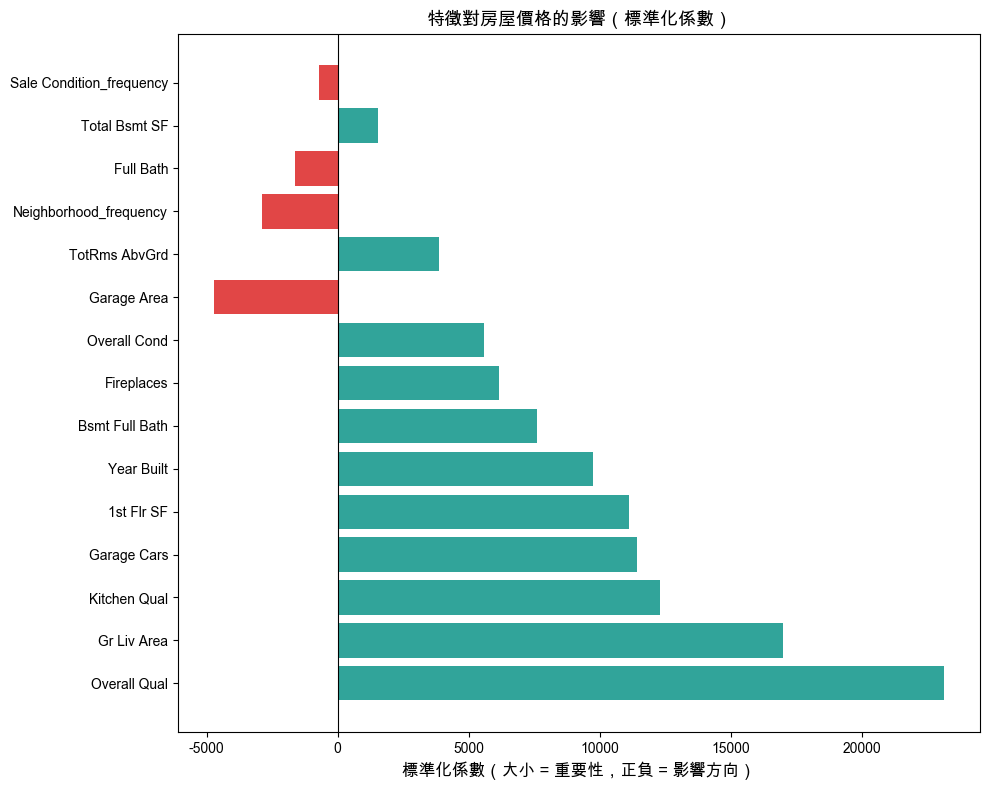

In [13]:
# 係數解讀（標準化後，可比較大小）

# 先標準化再訓練線性迴歸，以得到可比較的係數
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled_lr, y_train)

# 建立係數DataFrame
coef_df = pd.Series(
    lr_scaled.coef_,
    index=feature_df.columns
).sort_values(key=abs, ascending=False)

print("\n" + "=" * 70)
print("係數解讀（標準化後，可比較大小）")
print("=" * 70)
print(f"{'特徵':<20} {'係數':<15} {'方向':<20}")
print("-" * 70)

for feat, coef in coef_df.items():
    direction = '正相關 ↑' if coef > 0 else '負相關 ↓'
    print(f"{feat:<20} {coef:>+.4f}          {direction:<20}")

print("=" * 70)

# 視覺化：係數條形圖
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#DC2626' if v < 0 else '#0D9488' for v in coef_df.values]
ax.barh(coef_df.index, coef_df.values, color=colors, alpha=0.85)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('標準化係數（大小 = 重要性，正負 = 影響方向）', fontsize=12, fontweight='bold')
ax.set_title('特徵對房屋價格的影響（標準化係數）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 診斷分析：預測 vs. 真實值與殘差

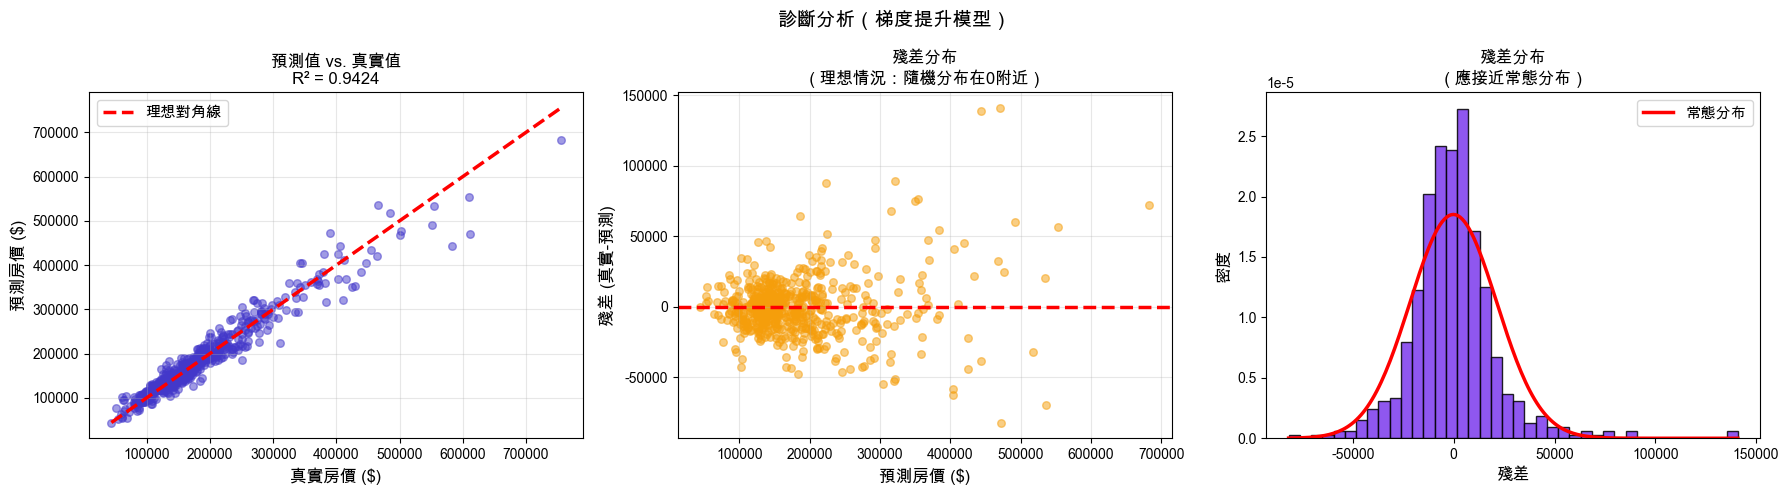


殘差統計
平均殘差: $        -188.52  （應接近 0）
殘差標準差: $    21,544.34
最大誤差: $      140,948.18
最小誤差: $      -81,936.38


In [14]:

# 用最佳的梯度提升模型進行診斷分析
# ⚠️ 重要：轉換標準化的預測值回原始單位
y_pred_scaled = best_model.predict(X_test_scaled)
y_pred_test = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① 預測 vs. 真實值（應該在對角線附近）
axes[0].scatter(y_test.values, y_pred_test, alpha=0.5, s=30, color='#4338CA')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=2.5, label='理想對角線')
axes[0].set_xlabel('真實房價 ($)', fontsize=12)
axes[0].set_ylabel('預測房價 ($)', fontsize=12)
axes[0].set_title(f'預測值 vs. 真實值\nR² = {r2_score(y_test, y_pred_test):.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ② 殘差 vs. 預測值（應該隨機分布在0線附近）
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=30, color='#F59E0B')
axes[1].axhline(0, color='r', lw=2.5, linestyle='--')
axes[1].set_xlabel('預測房價 ($)', fontsize=12)
axes[1].set_ylabel('殘差 (真實-預測)', fontsize=12)
axes[1].set_title('殘差分布\n（理想情況：隨機分布在0附近）',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ③ 殘差直方圖（應該接近常態分布）
axes[2].hist(residuals, bins=40, color='#7C3AED', alpha=0.85, density=True, edgecolor='black')
x_range = np.linspace(residuals.min(), residuals.max(), 200)
mu, sigma = residuals.mean(), residuals.std()
axes[2].plot(x_range, sp_stats.norm.pdf(x_range, mu, sigma), 'r-', lw=2.5, label='常態分布')
axes[2].set_xlabel('殘差', fontsize=12)
axes[2].set_ylabel('密度', fontsize=12)
axes[2].set_title('殘差分布\n（應接近常態分布）', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=11)

plt.suptitle('診斷分析（梯度提升模型）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 統計摘要
print("\n" + "=" * 70)
print("殘差統計")
print("=" * 70)
print(f"平均殘差: ${residuals.mean():>15,.2f}  （應接近 0）")
print(f"殘差標準差: ${residuals.std():>13,.2f}")
print(f"最大誤差: ${residuals.max():>16,.2f}")
print(f"最小誤差: ${residuals.min():>16,.2f}")
print("=" * 70)

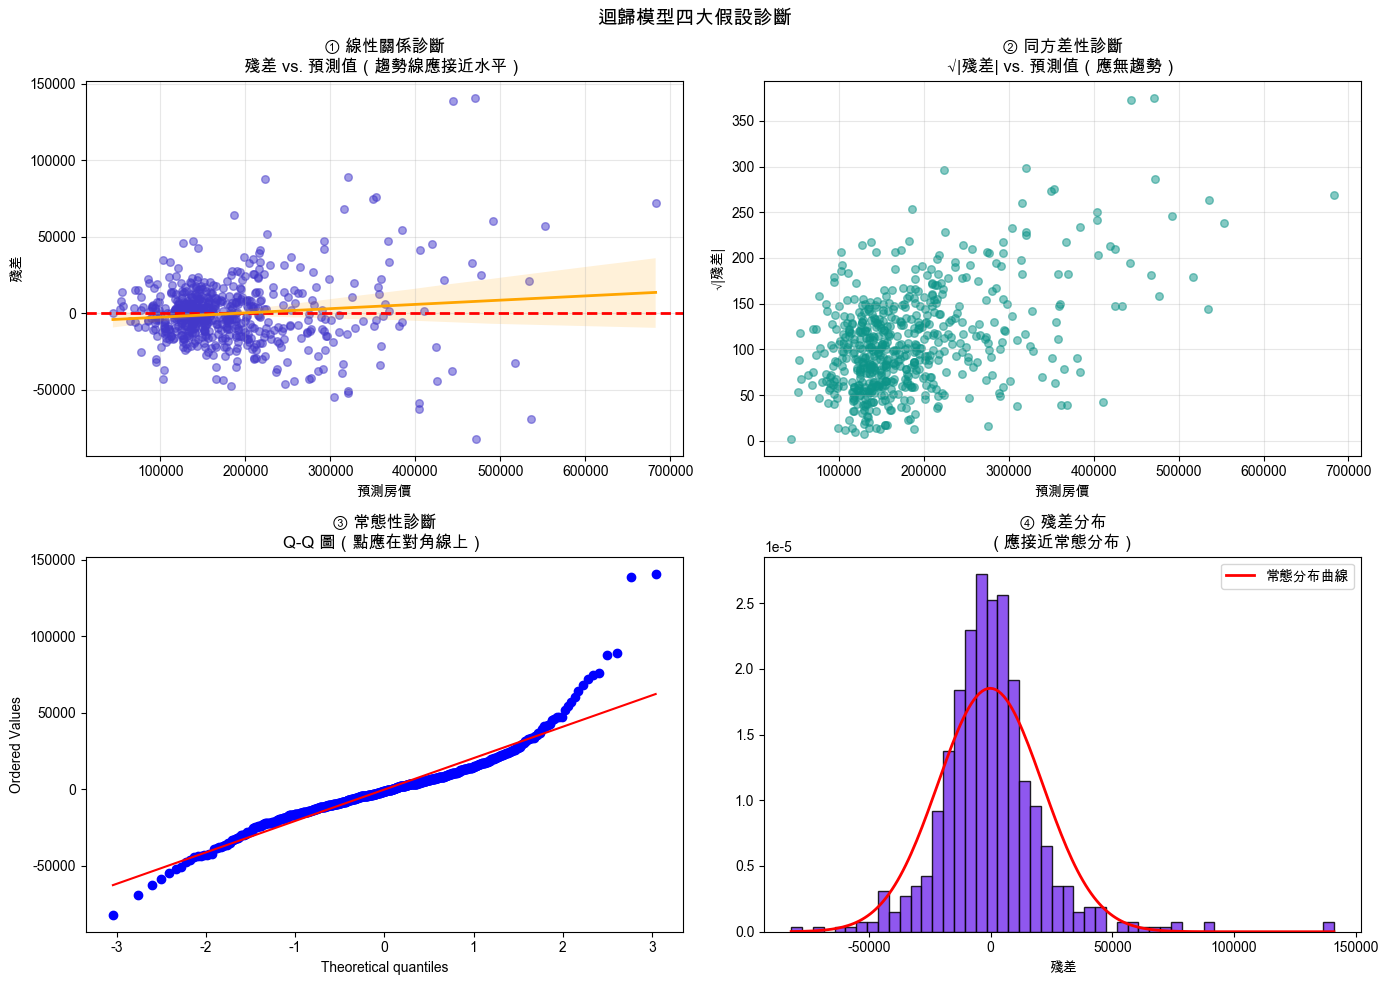


常態性檢定（Shapiro-Wilk）
檢定統計量: 0.8976
P-value: 0.0000
⚠️ 結論：殘差不完全符合常態分布（p < 0.05）


In [15]:
## 7. 四大假設診斷（回歸模型檢驗）

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ① 線性關係診斷：殘差 vs. 預測值（應該沒有明顯趨勢）
axes[0, 0].scatter(y_pred_test, residuals, alpha=0.5, s=30, color='#4338CA')
axes[0, 0].axhline(0, color='r', lw=2, linestyle='--')
sns.regplot(x=y_pred_test, y=residuals, scatter=False, ax=axes[0, 0],
            color='orange', line_kws={'lw': 2})
axes[0, 0].set_title('① 線性關係診斷\n殘差 vs. 預測值（趨勢線應接近水平）',
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('預測房價'); axes[0, 0].set_ylabel('殘差')
axes[0, 0].grid(True, alpha=0.3)

# ② 同方差性診斷：√|殘差| vs. 預測值（應該無趨勢）
axes[0, 1].scatter(y_pred_test, np.sqrt(np.abs(residuals)), alpha=0.5, s=30, color='#0D9488')
axes[0, 1].set_title('② 同方差性診斷\n√|殘差| vs. 預測值（應無趨勢）',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('預測房價'); axes[0, 1].set_ylabel('√|殘差|')
axes[0, 1].grid(True, alpha=0.3)

# ③ 常態性診斷：Q-Q 圖（點應在對角線上）
sp_stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('③ 常態性診斷\nQ-Q 圖（點應在對角線上）', fontsize=12, fontweight='bold')

# ④ 殘差分布直方圖（應接近常態分布）
axes[1, 1].hist(residuals, bins=50, color='#7C3AED', alpha=0.85, density=True, edgecolor='black')
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 1].plot(x_range, sp_stats.norm.pdf(x_range, mu, sigma),
                'r-', lw=2, label='常態分布曲線')
axes[1, 1].set_title('④ 殘差分布\n（應接近常態分布）', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('殘差')
axes[1, 1].legend()

plt.suptitle('迴歸模型四大假設診斷', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 常態性檢定
stat, p_value = sp_stats.shapiro(residuals[:500])  # 取樣本（樣本過大時）
print("\n" + "=" * 70)
print("常態性檢定（Shapiro-Wilk）")
print("=" * 70)
print(f"檢定統計量: {stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value > 0.05:
    print("✅ 結論：殘差符合常態分布（p > 0.05）")
else:
    print("⚠️ 結論：殘差不完全符合常態分布（p < 0.05）")
print("=" * 70)